[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/02_data_access/03_xarray_interop.ipynb)

# xarray interop

Hand an Easy-EO dataset to the xarray ecosystem and take it back again.

- **Data:** the bundled Sentinel-2 sample
- **Network:** only for the first download of the sample
- **Requires:** `pip install "easy-eo[xarray]"`

Easy-EO deliberately does not reimplement what xarray already does well - labelled dimensions, groupby, resampling over time, Dask-backed chunking. The conversion is a boundary you cross when you need those, not a wrapper you work through.

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo[xarray]"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
import numpy as np

from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()
scene = load_raster(sd.sentinel2_stacked)
scene.describe()

EEORasterDataset
  source      : /home/tommy/.cache/easy-eo/sentinel2_small.tif
  driver      : GTiff
  bands       : 4
  band names  : 1: blue, 2: green, 3: red, 4: nir
  size        : 1024 × 1024  (height × width)
  dtype       : uint16
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : none
  attrs       : none


## To xarray

`to_xarray()` returns a `DataArray` with the georeferencing attached through rioxarray, so the `.rio` accessor works immediately.

In [3]:
da = scene.to_xarray()
da

<xarray.DataArray (band: 4, y: 1024, x: 1024)> Size: 8MB
array([[[1754, 1790, 1932, ..., 1530, 1628, 1702],
        [1918, 1918, 2078, ..., 1405, 1403, 1404],
        [1506, 1622, 1780, ..., 1422, 1439, 1419],
        ...,
        [1336, 1328, 1300, ..., 1408, 1285, 1217],
        [1292, 1304, 1309, ..., 1255, 1166, 1172],
        [1327, 1304, 1330, ..., 1220, 1134, 1127]],

       [[1950, 2244, 2210, ..., 1986, 2030, 2078],
        [2060, 2172, 2472, ..., 1972, 1958, 1952],
        [1830, 1918, 2120, ..., 2004, 2012, 1992],
        ...,
        [1611, 1634, 1610, ..., 1614, 1498, 1473],
        [1613, 1620, 1622, ..., 1367, 1389, 1320],
        [1640, 1633, 1606, ..., 1344, 1289, 1290]],

       [[2284, 2416, 2308, ..., 1592, 1716, 1812],
        [2322, 2200, 2330, ..., 1475, 1482, 1514],
        [2158, 2580, 2140, ..., 1452, 1459, 1454],
        ...,
        [1342, 1353, 1326, ..., 1512, 1301, 1231],
        [1352, 1335, 1347, ..., 1314, 1189, 1161],
        [1364, 1353, 1350, ..., 1284, 1174, 1149]],

       [[3238, 3648, 4176, ..., 5396, 4896, 4512],
        [2968, 3432, 3980, ..., 6180, 6064, 5872],
        [2900, 3822, 4484, ..., 6304, 6324, 6252],
        ...,
        [5772, 5884, 5840, ..., 3576, 5028, 5588],
        [5816, 5808, 5660, ..., 3486, 4528, 4408],
        [5736, 5736, 5544, ..., 3036, 3674, 3634]]], dtype=uint16)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 8kB 5.35e+06 5.35e+06 ... 5.34e+06 5.34e+06
  * x            (x) float64 8kB 3.777e+05 3.777e+05 ... 3.879e+05 3.88e+05
    spatial_ref  int64 8B 0
Attributes:
    long_name:   ('blue', 'green', 'red', 'nir')
    _FillValue:  0

In [4]:
print("dims   :", da.dims)
print("shape  :", da.shape)
print("dtype  :", da.dtype)
print("coords :", list(da.coords))
print("\ncrs    :", da.rio.crs)
print("nodata :", da.rio.nodata)
print("transform:", da.rio.transform())

dims   : ('band', 'y', 'x')
shape  : (4, 1024, 1024)
dtype  : uint16
coords : ['band', 'y', 'x', 'spatial_ref']

crs    : EPSG:32633
nodata : 0
transform: | 10.00, 0.00, 377720.00|
| 0.00,-10.00, 5350470.00|
| 0.00, 0.00, 1.00|


Band names travel as the `long_name` attribute, which is the convention rioxarray and GDAL use. The `band` coordinate itself stays numeric.

In [5]:
print("band coord:", da.coords["band"].values)
print("long_name :", da.attrs["long_name"])

band coord: [1 2 3 4]
long_name : ('blue', 'green', 'red', 'nir')


Promoting the names to the coordinate makes xarray selection read the way Easy-EO's does - worth the one line.

In [6]:
named = da.assign_coords(band=list(da.attrs["long_name"]))

nir = named.sel(band="nir")
print(nir.shape, "->", float(nir.mean()))

(1024, 1024) -> 4606.8037576675415


## What xarray gives you

Labelled reductions, arithmetic across dimensions, and everything else in the xarray API.

In [7]:
print("per-band means:")
print(named.mean(dim=("y", "x")).to_series().round(1))

per-band means:
band
blue     1552.9
green    1898.0
red      1780.3
nir      4606.8
dtype: float64


One trap carries over from NumPy: these bands are **unsigned** 16-bit, so a subtraction that goes negative wraps around rather than going below zero. Cast to a float dtype before doing index arithmetic by hand - in xarray exactly as in Easy-EO.

In [8]:
reflectance = named.astype("float32")

ndvi = (reflectance.sel(band="nir") - reflectance.sel(band="red")) / (
    reflectance.sel(band="nir") + reflectance.sel(band="red")
)

print(f"NDVI computed in xarray : {float(ndvi.mean()):.4f}")
print(f"NDVI computed in Easy-EO: {float(np.nanmean(scene.ndvi(red='red', nir='nir').get_band(1))):.4f}")

NDVI computed in xarray : 0.4434
NDVI computed in Easy-EO: 0.4434


In [9]:
still_integer = (named.sel(band="nir") - named.sel(band="red")) / (
    named.sel(band="nir") + named.sel(band="red")
)
print(f"without the cast        : {float(still_integer.mean()):.4f}  <- wrapped, and wrong")

without the cast        : 0.4461  <- wrapped, and wrong


Coordinate-based selection is the thing xarray does that Easy-EO does not - slice by real-world position rather than pixel index.

In [10]:
window = named.sel(x=slice(380000, 382000), y=slice(5348000, 5346000))
print("selected by coordinate:", window.shape)

selected by coordinate: (4, 200, 200)


## Back from xarray

`from_xarray` converts a georeferenced `DataArray` back into an `EEORasterDataset`, so a detour through xarray can rejoin an Easy-EO chain.

In [11]:
from eeo import from_xarray

back = from_xarray(da)
back.describe()

EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 4
  band names  : 1: blue, 2: green, 3: red, 4: nir
  size        : 1024 × 1024  (height × width)
  dtype       : uint16
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : 0
  timestamp   : none
  attrs       : none


## The round trip is lossless

CRS, transform, nodata, dtype, band count, band names and values all survive in both directions.

In [12]:
checks = {
    "values": np.array_equal(back.to_array(), scene.to_array()),
    "crs": back.get_crs() == scene.get_crs(),
    "transform": back.get_transform() == scene.get_transform(),
    "shape": back.get_shape() == scene.get_shape(),
    "dtype": back.get_metadata()["dtype"] == scene.get_metadata()["dtype"],
    "nodata": back.get_metadata()["nodata"] == scene.get_metadata()["nodata"],
    "band names": back.band_names == scene.band_names,
}

for name, passed in checks.items():
    print(f"{name:12s} {'ok' if passed else 'DIFFERS'}")

values       ok
crs          ok
transform    ok
shape        ok
dtype        ok
nodata       ok
band names   ok


## Bringing a computed array back

The practical pattern: compute in xarray, return to Easy-EO for the raster operations and I/O.

In [13]:
ndvi_da = ndvi.expand_dims("band").astype("float32")
ndvi_da = ndvi_da.rio.write_crs(scene.get_crs()).rio.write_nodata(np.nan)

ndvi_ds = from_xarray(ndvi_da)
ndvi_ds.band_names = ["ndvi"]
ndvi_ds.describe()

EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 1
  band names  : 1: ndvi
  size        : 1024 × 1024  (height × width)
  dtype       : float32
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : nan
  timestamp   : none
  attrs       : none


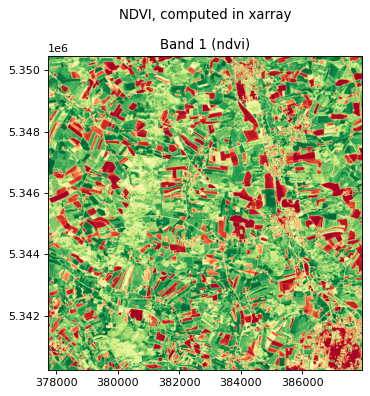

In [14]:
ndvi_ds.plot_raster(cmap="RdYlGn", title="NDVI, computed in xarray")

## When to reach for xarray instead

Use xarray directly when your problem is genuinely multi-dimensional - a time series over many dates, per-pixel regressions, or anything larger than memory that needs Dask chunking. Use Easy-EO when the work is raster operations on one or a few scenes and you want them in a few readable lines.

They are not in competition: `to_xarray()` is there precisely so you can start in Easy-EO and leave when the problem outgrows it.

In [15]:
for ds in (scene, back, ndvi_ds):
    ds.close()
print("closed")

closed


## Next

- **[../03_real_world/04_terrain_analysis_with_dem](../03_real_world/04_terrain_analysis_with_dem.ipynb)** - a full offline analysis